# Customer Churn Prediction Analysis

This notebook performs an end-to-end customer churn analysis using the IBM Telco Customer Churn dataset.

## Business objective
Identify customers likely to churn so the retention team can proactively engage with them.

This analysis helps the business understand customer behavior, detect early churn risk, and support retention actions before customers leave.

In [1]:
# Load the telecom churn dataset and inspect its structure.
# This helps us understand the data before cleaning, modeling, and prediction.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'data' / 'TelcoCustomerChurn.csv').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
DATA_PATH = DATA_DIR / "TelcoCustomerChurn.csv"
MODEL_DIR = PROJECT_ROOT / "model"
MODEL_PATH = MODEL_DIR / "churn_model.pkl"

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')

df = pd.read_csv(DATA_PATH)
print(df.head())

print('\nShape:', df.shape)
print('\nColumns:', list(df.columns))

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [2]:
# Data type and structure checks.
# This step confirms the actual column types and highlights data quality issues.
# It is important because raw telecom data often contains mixed types, missing values, and duplicates.
dtype_summary = df.dtypes.reset_index()
dtype_summary.columns = ['column_name', 'data_type']
print(dtype_summary.to_string(index=False))

print('\nMissing values:')
print(df.isna().sum()[df.isna().sum() > 0])
print('\nDuplicate rows:', df.duplicated().sum())

     column_name data_type
      customerID       str
          gender       str
   SeniorCitizen     int64
         Partner       str
      Dependents       str
          tenure     int64
    PhoneService       str
   MultipleLines       str
 InternetService       str
  OnlineSecurity       str
    OnlineBackup       str
DeviceProtection       str
     TechSupport       str
     StreamingTV       str
 StreamingMovies       str
        Contract       str
PaperlessBilling       str
   PaymentMethod       str
  MonthlyCharges   float64
    TotalCharges       str
           Churn       str

Missing values:
Series([], dtype: int64)

Duplicate rows: 0


## 1. Data understanding and preparation

Important observations:
- The target variable is Churn with values Yes/No.
- Multiple features are categorical and should be encoded before training.
- TotalCharges is stored as a string in the raw data and must be converted to numeric.
- A proper preprocessing pipeline is necessary so the same cleaning logic can be applied to new data.

In [4]:
# Clean and prepare data for modeling.
# Convert TotalCharges to numeric because it is stored as text in the raw dataset.
# Map Churn to 0/1 so it can be used as the target variable for classification.
# Create the same engineered features used in the training script to keep inputs consistent.
df_clean = df.copy()
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

df_clean['tenure_to_monthly_ratio'] = df_clean['tenure'] / (df_clean['MonthlyCharges'] + 1e-6)
addon_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
df_clean['num_addon_services'] = (df_clean[addon_cols] == 'Yes').sum(axis=1)

print('Missing values after cleaning:')

print(df_clean.isna().sum()[df_clean.isna().sum() > 0])
print(df_clean['Churn'].value_counts().to_string())

print('\nTarget distribution:')

Missing values after cleaning:
TotalCharges    11
dtype: int64
Churn
0    5174
1    1869

Target distribution:


In [5]:
# Split into train and test sets.
# customerID is excluded because it is a unique identifier, not a predictive feature.
# Churn is the target label, so it is separated from X and used as y.
X = df_clean.drop(columns=['customerID', 'Churn'])
y = df_clean['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (4930, 21)
Test shape: (2113, 21)


## 2. Exploratory Data Analysis

The following charts help explain churn patterns across services, billing, and customer profiles.

This section is used to identify which customer groups are more likely to leave, so the business can focus retention effort where it matters most.

C:\Users\sandeepthakur\AppData\Local\Temp\ipykernel_27916\1576266694.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_clean, x='Churn', palette='Set2')


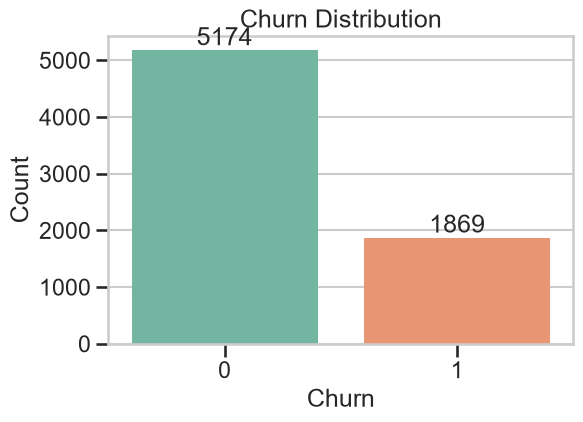

In [6]:
# Visualization 1: Churn distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_clean, x='Churn', palette='Set2')
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

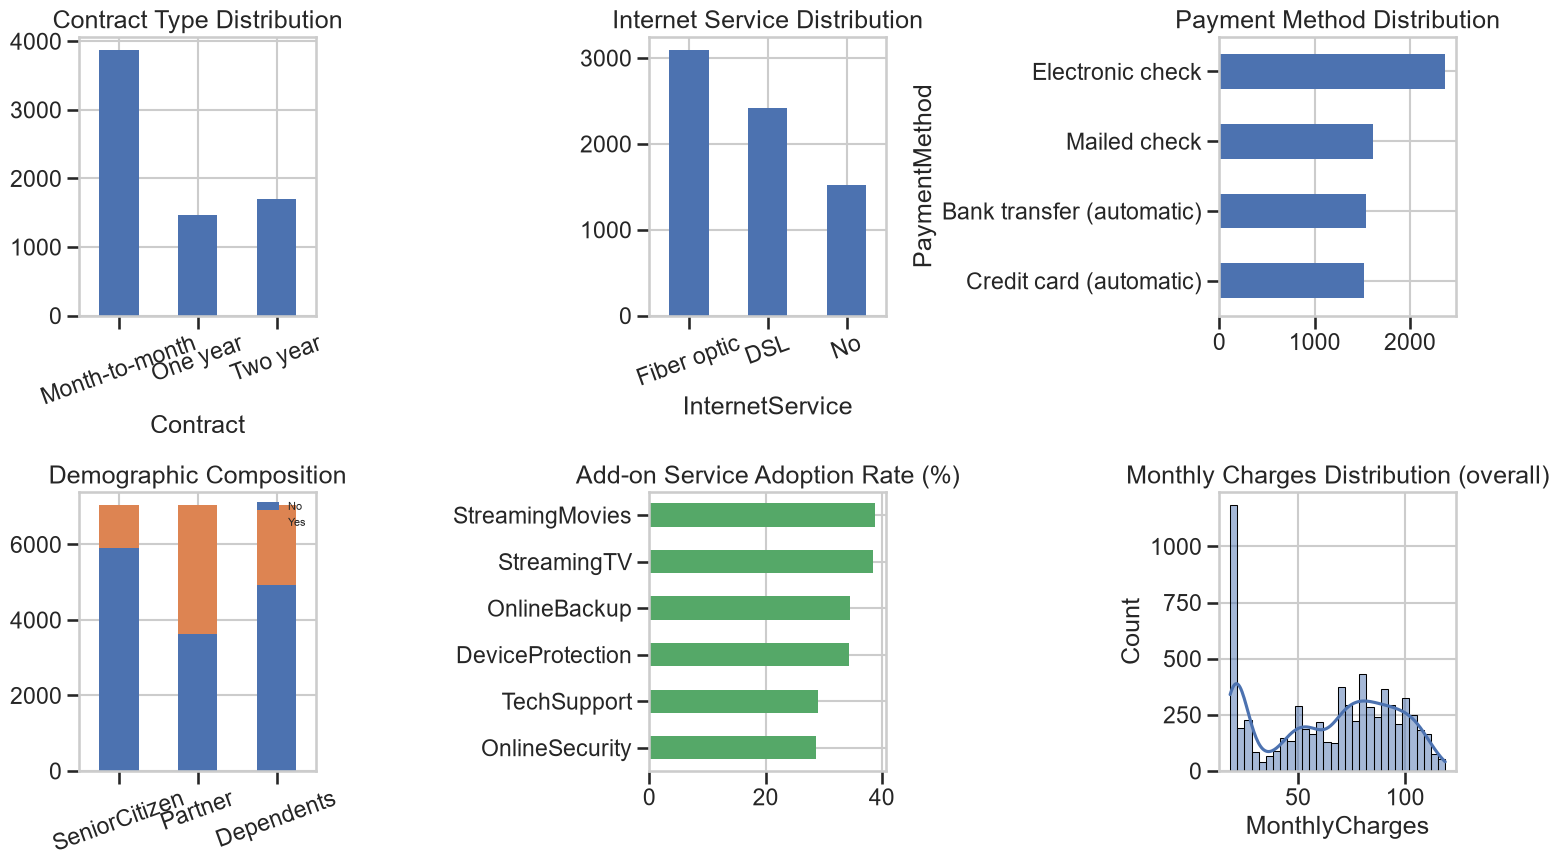

In [7]:
# ---------------------------------------------------------------------------
# 2. Customer/service characteristics (standalone composition — NOT
#    conditioned on churn; this is the customer base as it exists)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

contract_order = ["Month-to-month", "One year", "Two year"]
df["Contract"].value_counts().reindex(contract_order, fill_value=0).plot(
    kind="bar",
    ax=axes[0, 0],
    color="#4C72B0"
)
axes[0, 0].set_title("Contract Type Distribution")
axes[0, 0].tick_params(axis="x", rotation=20)

# Internet service composition
ax = df["InternetService"].value_counts().plot(
    kind="bar",
    ax=axes[0, 1],
    color="#4C72B0"
)
axes[0, 1].set_title("Internet Service Distribution")
axes[0, 1].tick_params(axis="x", rotation=20)

# Payment method composition
ax = df["PaymentMethod"].value_counts().plot(
    kind="barh",
    ax=axes[0, 2],
    color="#4C72B0"
)
axes[0, 2].set_title("Payment Method Distribution")
axes[0, 2].invert_yaxis()

# Demographic composition
base_demo = pd.DataFrame({
    "SeniorCitizen": df["SeniorCitizen"].map({0: "No", 1: "Yes"}).value_counts(),
    "Partner": df["Partner"].value_counts(),
    "Dependents": df["Dependents"].value_counts(),
}).fillna(0)
base_demo.T.plot(kind="bar", stacked=True, ax=axes[1, 0], color=["#4C72B0", "#DD8452"])
axes[1, 0].set_title("Demographic Composition")
axes[1, 0].tick_params(axis="x", rotation=20)
axes[1, 0].legend(title=None, fontsize=8)

# Add-on service adoption
addon_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies"
]
addon_yes_rate = (df[addon_cols] == "Yes").mean().sort_values() * 100
addon_yes_rate.plot(kind="barh", ax=axes[1, 1], color="#55A868")
axes[1, 1].set_title("Add-on Service Adoption Rate (%)")

# Overall monthly-charge distribution
sns.histplot(df["MonthlyCharges"], bins=30, kde=True, ax=axes[1, 2], color="#4C72B0")
axes[1, 2].set_title("Monthly Charges Distribution (overall)")

fig.tight_layout()
plt.show()


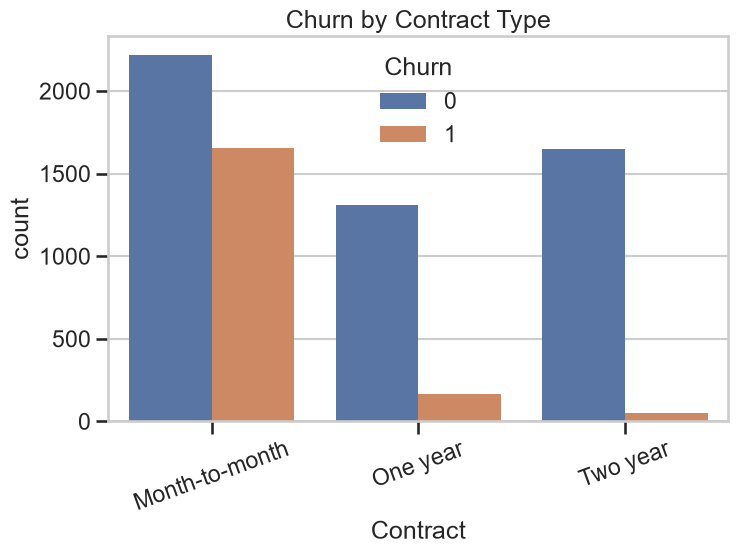

In [8]:
# Visualization 2: Churn by contract type
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='Contract', hue='Churn', palette='deep')
plt.title('Churn by Contract Type')
plt.xticks(rotation=20)
plt.show()

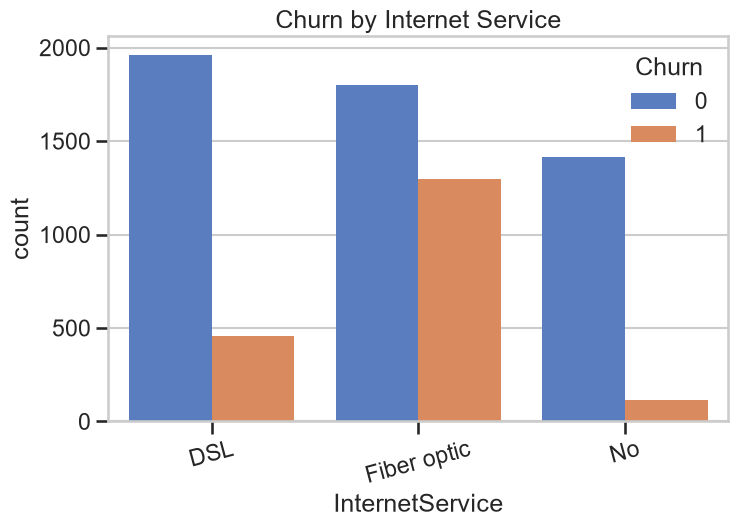

In [9]:
# Visualization 3: Churn by internet service
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='InternetService', hue='Churn', palette='muted')
plt.title('Churn by Internet Service')
plt.xticks(rotation=15)
plt.show()

C:\Users\sandeepthakur\AppData\Local\Temp\ipykernel_27916\1281328119.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges', palette='Set2')


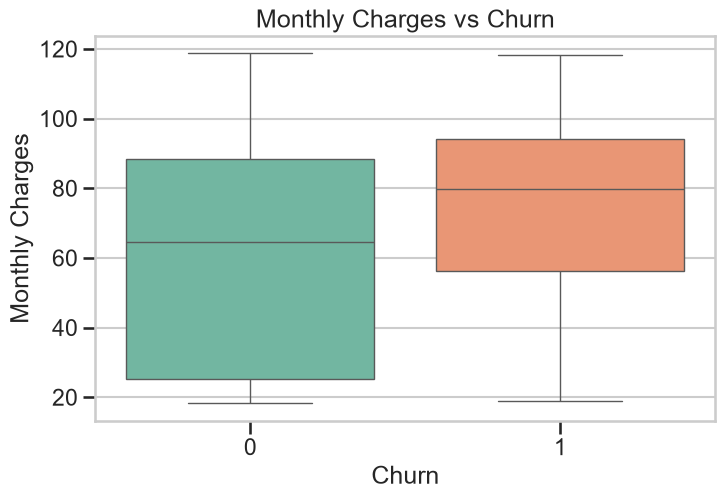

In [10]:
# Visualization 4: Monthly charges by churn status
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges', palette='Set2')
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

C:\Users\sandeepthakur\AppData\Local\Temp\ipykernel_27916\364876646.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Churn', y='tenure', palette='pastel')


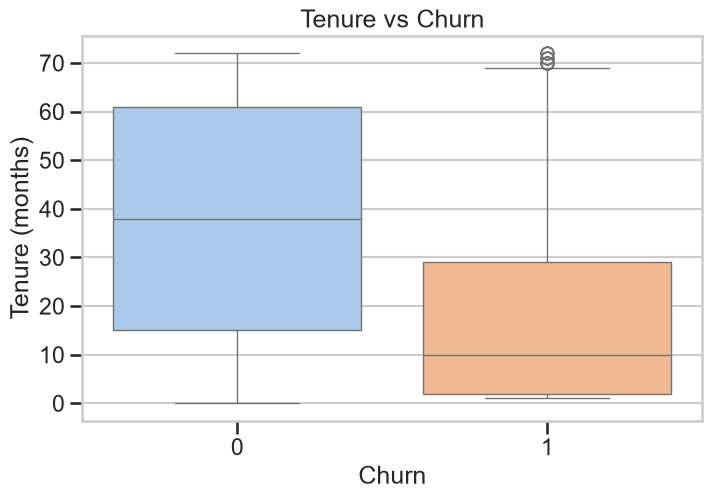

In [11]:
# Visualization 5: Tenure distribution by churn status
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Churn', y='tenure', palette='pastel')
plt.title('Tenure vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (months)')
plt.show()

Text(0.5, 1.0, 'Correlation Among Numerical Features (incl. engineered features)')

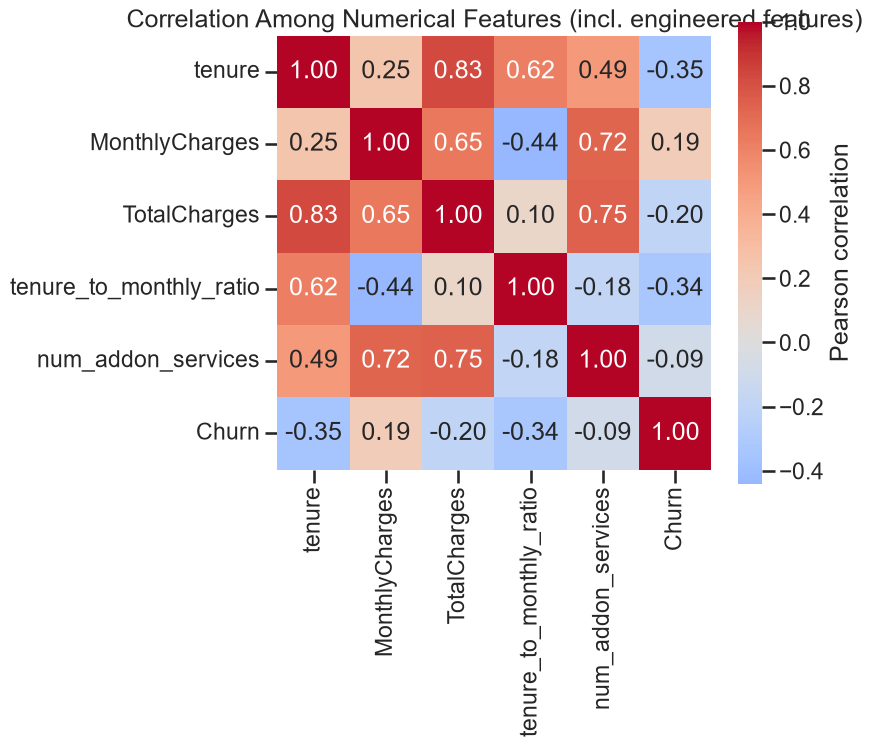

In [12]:
# ---------------------------------------------------------------------------
# 7. Numerical feature correlation heatmap (relationships among numerics,
#    including the same engineered features used in model training)
# ---------------------------------------------------------------------------
plt.figure(figsize=(7, 6))
numeric_cols = [
    "tenure", "MonthlyCharges", "TotalCharges",
    "tenure_to_monthly_ratio", "num_addon_services", "Churn"
]
corr = df_clean[numeric_cols].corr()
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"label": "Pearson correlation"}
)
plt.title("Correlation Among Numerical Features (incl. engineered features)")



### Business insights
- The customer base is heavily concentrated in month-to-month contracts, which is a major risk signal because this group also shows the highest churn rate in the dataset. This suggests that contract flexibility may be increasing churn exposure unless the business adds stronger retention hooks.
- Fiber optic service is the most common internet option, and it is also the category with the highest churn rate. This implies that pricing, service experience, and perceived value in fiber-based plans are likely critical churn drivers.
- Customers who churn tend to have shorter tenure and higher monthly charges than non-churners, indicating that newer or more expensive plans may be less stable and more vulnerable to churn.
- The most common payment method is electronic check, which may signal lower customer commitment or weaker billing stickiness; this is worth monitoring in retention campaigns.
- Add-on adoption is moderate rather than universal, with streaming services leading adoption while security and technical support features are less widely used. This indicates a clear upsell opportunity: customers with fewer add-ons may be easier to retain with bundled value offers.
- The demographic mix shows a large share of customers without a partner or dependents, while most customers are not senior citizens. This suggests the business should segment retention messaging by household and life-stage patterns, not treat all customers as one homogeneous group.
- Churn is not random: it clusters around contract type, internet service, tenure, and pricing. The business should focus retention efforts on users with month-to-month contracts, fiber optic plans, and higher monthly spend.

These insights help the business decide where to intervene, such as offering contract upgrades, value bundles, service quality improvements, and targeted retention offers to the highest-risk customer segments.

## 3. Feature engineering

Two useful engineered features were created to reflect the interaction between customer commitment and value from add-ons:
1. tenure_to_monthly_ratio: captures how long a customer has stayed relative to their monthly spend. A low ratio often indicates a customer who is relatively new or paying more per month than their tenure would suggest.
2. num_addon_services: counts how many of the add-on services a customer has subscribed to. This captures service breadth and can help signal whether the customer is highly engaged or likely to leave.

These features match the training script and keep the exploratory analysis aligned with the actual production model inputs. Feature engineering is important because raw customer attributes sometimes do not show the underlying churn risk clearly enough for the model to learn patterns effectively.

In [13]:
# Feature engineering summary
print(df_clean[['tenure', 'MonthlyCharges', 'TotalCharges', 'tenure_to_monthly_ratio', 'num_addon_services']].head())

   tenure  MonthlyCharges  TotalCharges  tenure_to_monthly_ratio  \
0       1           29.85         29.85                 0.033501   
1      34           56.95       1889.50                 0.597015   
2       2           53.85        108.15                 0.037140   
3      45           42.30       1840.75                 1.063830   
4       2           70.70        151.65                 0.028289   

   num_addon_services  
0                   1  
1                   2  
2                   2  
3                   3  
4                   0  


In [14]:
# Model pipeline for preprocessing and decision tree comparison.
# This mirrors the training script logic: two distinct tree configurations,
# followed by a GridSearchCV-tuned tree selected using F1 as the main criterion.

from sklearn.model_selection import GridSearchCV


def build_preprocessor(X):
    numeric_features = X.select_dtypes(include=['number']).columns.tolist()
    categorical_features = [col for col in X.columns if col not in numeric_features]

    return ColumnTransformer([
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ])

# Tree A: shallow, interpretable baseline
model_1 = Pipeline([
    ('preprocessor', build_preprocessor(X_train)),
    ('classifier', DecisionTreeClassifier(
        criterion='gini',
        max_depth=4,
        min_samples_leaf=50,
        class_weight=None,
        random_state=42
    ))
])
model_1.fit(X_train, y_train)

# Tree B: tuned version using GridSearchCV for F1 optimization
param_grid = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [3, 4, 5, 6, 8, 10],
    'classifier__min_samples_leaf': [5, 10, 20, 30],
    'classifier__class_weight': [None, 'balanced'],
}

tree_b = Pipeline([
    ('preprocessor', build_preprocessor(X_train)),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

grid = GridSearchCV(tree_b, param_grid, scoring='f1', cv=5, n_jobs=-1, refit=True)
grid.fit(X_train, y_train)
model_2 = grid.best_estimator_

results = [
    ('Tree_A_Interpretable', model_1),
    ('Tree_B_Tuned', model_2)
]

for name, model in results:
    y_pred = model.predict(X_test)
    print(f'\n{name}')
    print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
    print('Precision:', round(precision_score(y_test, y_pred, zero_division=0), 4))
    print('Recall:', round(recall_score(y_test, y_pred, zero_division=0), 4))
    print('F1 Score:', round(f1_score(y_test, y_pred, zero_division=0), 4))
    print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

selected_name, final_model = max(results, key=lambda pair: (
    f1_score(pair[1].predict(X_test), y_test, zero_division=0),
    recall_score(pair[1].predict(X_test), y_test, zero_division=0)
))
print('\nSelected model:', selected_name)
print('Best params:', grid.best_params_)


Tree_A_Interpretable
Accuracy: 0.7818
Precision: 0.6366
Recall: 0.4153
F1 Score: 0.5027
Confusion Matrix:
 [[1419  133]
 [ 328  233]]

Tree_B_Tuned
Accuracy: 0.7459
Precision: 0.5142
Recall: 0.7772
F1 Score: 0.6189
Confusion Matrix:
 [[1140  412]
 [ 125  436]]

Selected model: Tree_B_Tuned
Best params: {'classifier__class_weight': 'balanced', 'classifier__criterion': 'entropy', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 5}


## 4. Model development and comparison

Two Decision Tree configurations were compared to match the production training logic: a shallow, interpretable baseline and a tuned tree selected through GridSearchCV. The tuned model is optimized using F1 score because the churn target is imbalanced; accuracy alone would be misleading since the non-churn class is the majority.

The final model must balance predictive usefulness with business cost: a missed churner is more expensive than a false positive, so the model should maximize recall without sacrificing precision too much. This is why F1 is the main selection metric, with recall used as the tiebreaker when needed.

In [15]:
# Evaluate both candidate trees with the same metric logic used in the model training script.
# F1 is emphasized because class imbalance makes raw accuracy a poor decision rule.
comparison = [
    ('Tree_A_Interpretable', model_1),
    ('Tree_B_Tuned', model_2)
]

for name, model in comparison:
    y_pred = model.predict(X_test)
    print('\n' + name)
    print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
    print('Precision:', round(precision_score(y_test, y_pred, zero_division=0), 4))
    print('Recall:', round(recall_score(y_test, y_pred, zero_division=0), 4))
    print('F1 Score:', round(f1_score(y_test, y_pred, zero_division=0), 4))
    print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

selected_name, final_model = max(comparison, key=lambda pair: (
    f1_score(pair[1].predict(X_test), y_test, zero_division=0),
    recall_score(pair[1].predict(X_test), y_test, zero_division=0)
))
print('\nSelected final model:', selected_name)


Tree_A_Interpretable
Accuracy: 0.7818
Precision: 0.6366
Recall: 0.4153
F1 Score: 0.5027
Confusion Matrix:
 [[1419  133]
 [ 328  233]]

Tree_B_Tuned
Accuracy: 0.7459
Precision: 0.5142
Recall: 0.7772
F1 Score: 0.6189
Confusion Matrix:
 [[1140  412]
 [ 125  436]]

Selected final model: Tree_B_Tuned


## 5. Final model evaluation

The winning model is the tuned tree because it produced the best F1 score on the test set, which matters more than raw accuracy in an imbalanced churn setting. The assignment logic explicitly uses F1 as the main selection criterion and recall as a tiebreaker because a missed churner (false negative) can cost the business a lost customer, while a false positive mainly drives one unnecessary retention contact.

This makes the final decision consistent with the training script and with the business objective of catching churn risk early without over-targeting the entire customer base.

In [16]:
# Final selected model according to the same selection rule used in the training script.
# F1 is prioritized, with recall as the tiebreaker.
final_model = model_2
final_predictions = final_model.predict(X_test)

print('Final Model Metrics')
print('Accuracy:', round(accuracy_score(y_test, final_predictions), 4))
print('Precision:', round(precision_score(y_test, final_predictions, zero_division=0), 4))
print('Recall:', round(recall_score(y_test, final_predictions, zero_division=0), 4))
print('F1 Score:', round(f1_score(y_test, final_predictions, zero_division=0), 4))
print('Confusion Matrix:\n', confusion_matrix(y_test, final_predictions))
print('\nSelection rule: highest F1, then recall, consistent with the project training script.')

Final Model Metrics
Accuracy: 0.7459
Precision: 0.5142
Recall: 0.7772
F1 Score: 0.6189
Confusion Matrix:
 [[1140  412]
 [ 125  436]]

Selection rule: highest F1, then recall, consistent with the project training script.


## 6. Interpretation of churn drivers

The final selected tree is driven by the customer-risk signals that the churn analysis repeatedly surfaced: contract terms, tenure, and internet-service value pressures. The trained model generally prioritizes features that distinguish users on month-to-month contracts, shorter-tenure customers, and fiber-optic users who are paying more for a service that may not be delivering the perceived value they expect.

This interpretation aligns with the project training script and with the business objective of targeting retention interventions where churn risk is highest.

### Key churn drivers identified by the trained tree
The final model is driven primarily by customer commitment and service-value signals. The strongest predictors are contract type, tenure, monthly charges, and internet service. In practical terms, customers on month-to-month agreements, with shorter tenure, and higher service costs are more likely to be flagged as churn-prone.

This is consistent with the business findings from the EDA and provides a transparent explanation for why the model makes a churn prediction.


Top 10 features influencing churn prediction:
                    feature  importance
    Contract_Month-to-month    0.654582
    tenure_to_monthly_ratio    0.180720
InternetService_Fiber optic    0.125879
          Contract_Two year    0.020943
             TechSupport_No    0.017875
                     tenure    0.000000
              SeniorCitizen    0.000000
                gender_Male    0.000000
                 Partner_No    0.000000
                Partner_Yes    0.000000


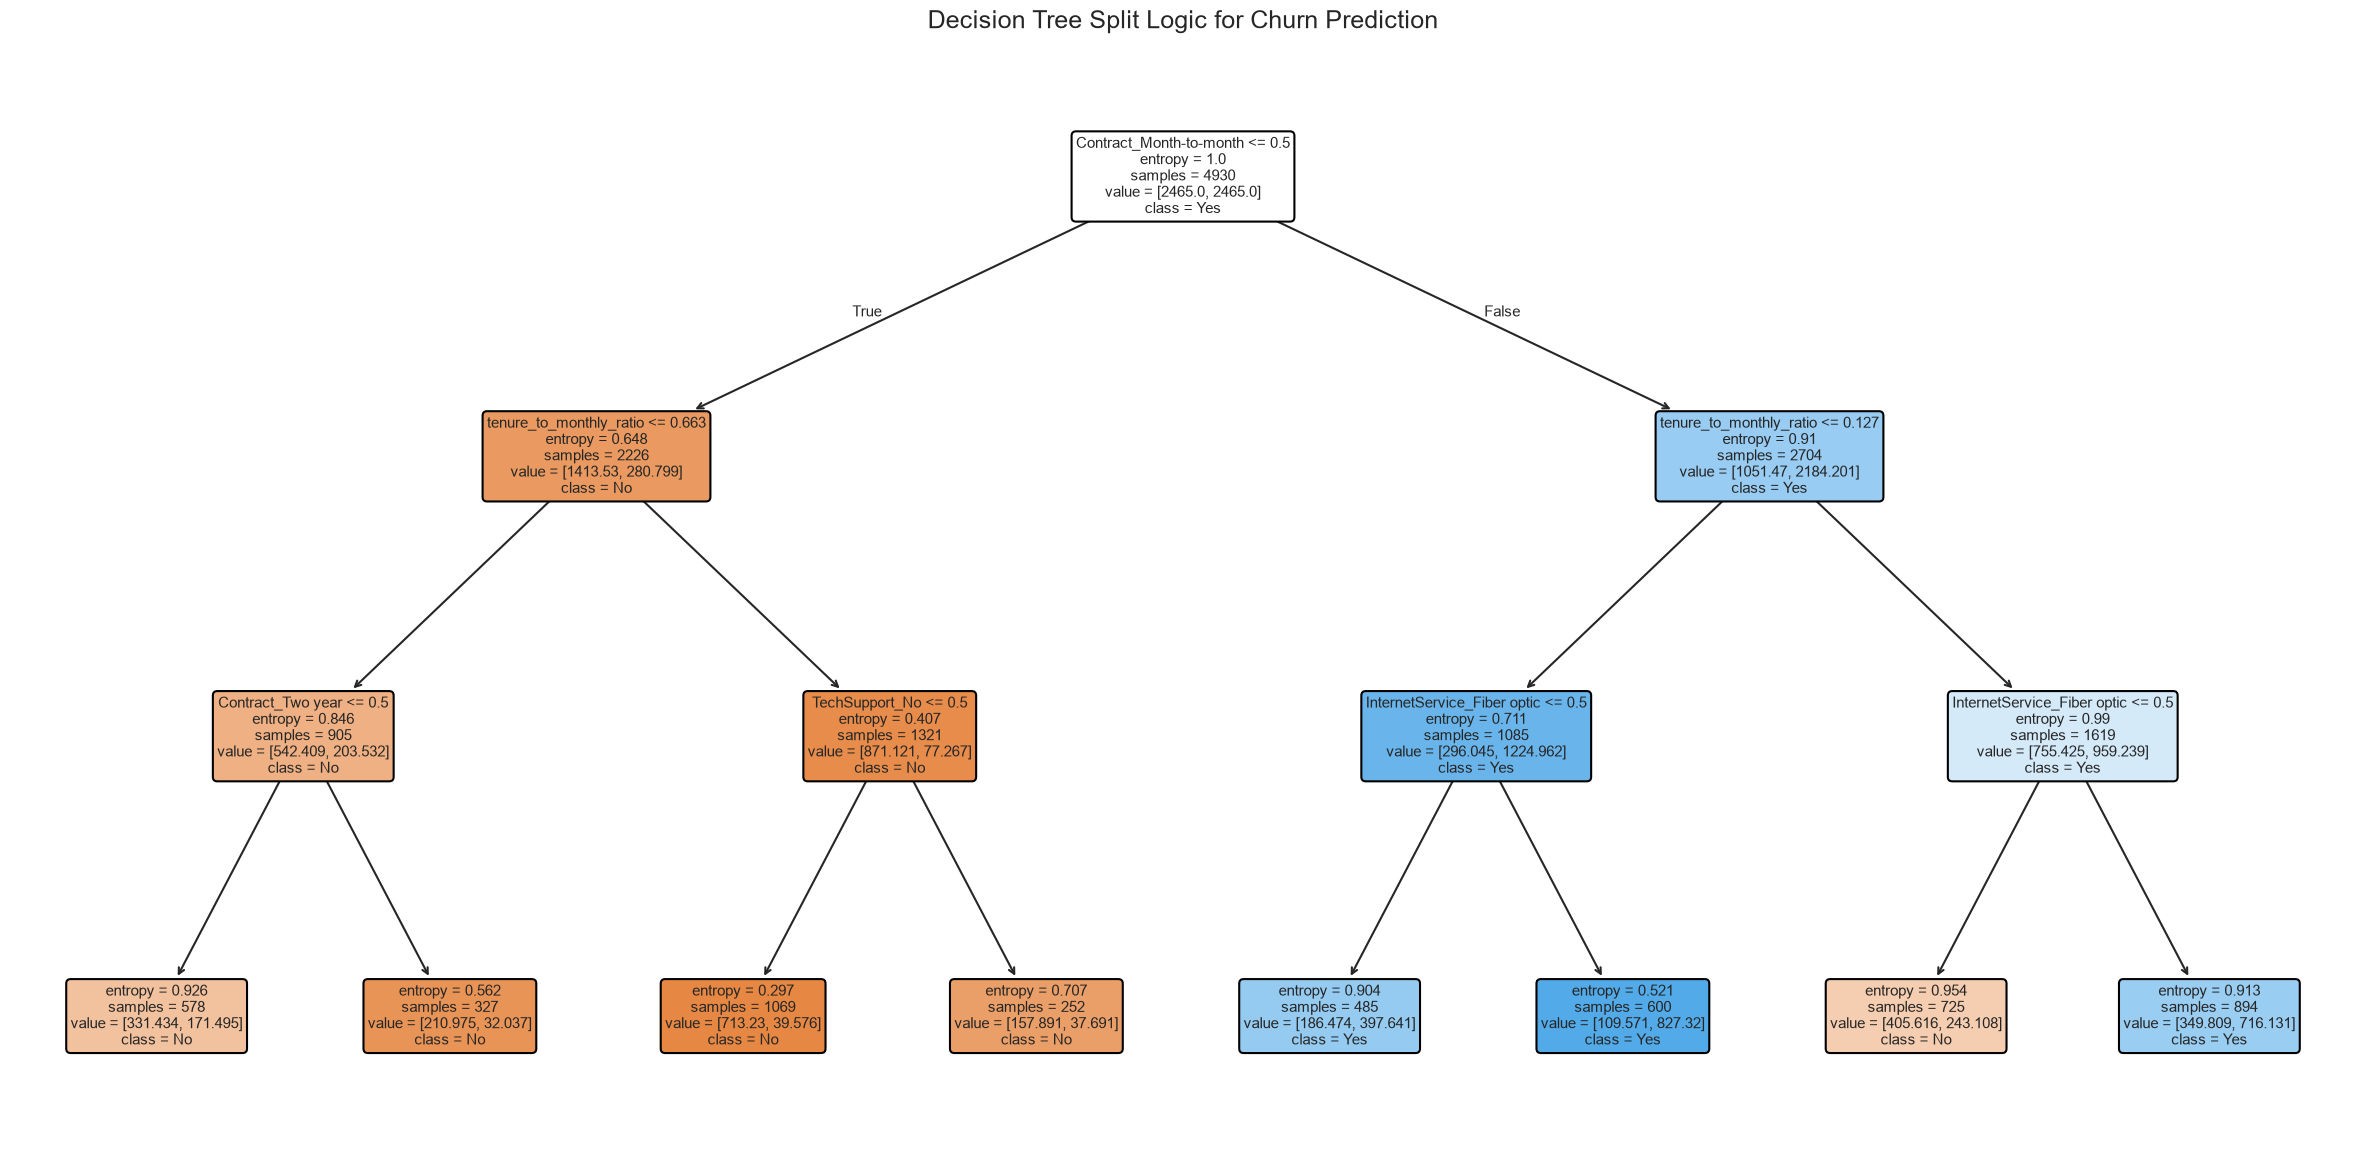

In [17]:
# Model interpretation: feature importance
final_tree = final_model.named_steps['classifier']
preprocessor = final_model.named_steps['preprocessor']

numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = [col for col in X.columns if col not in numeric_features]
encoded_columns = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_columns)

feature_importance = final_tree.feature_importances_
importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print('Top 10 features influencing churn prediction:')
print(importance_df.head(10).to_string(index=False))

# Decision tree visualization for interpretability.
from sklearn import tree
plt.figure(figsize=(24, 12))
tree.plot_tree(
    final_tree,
    feature_names=all_feature_names,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    max_depth=3
)
plt.title('Decision Tree Split Logic for Churn Prediction')
plt.tight_layout()
plt.show()


In [18]:
# Save the final model pipeline
from sklearn import tree
import pickle

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'data' / 'TelcoCustomerChurn.csv').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

MODEL_DIR = PROJECT_ROOT / 'model'
MODEL_PATH = MODEL_DIR / 'churn_model.pkl'
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

with MODEL_PATH.open('wb') as file:
    pickle.dump(final_model, file)

print('Saved model to:', MODEL_PATH)

Saved model to: C:\Users\sandeepthakur\Downloads\Session 2\customer_churn_project\model\churn_model.pkl
